- [ ] Usar la métrica que está en el EVA
- [ ] Variables en punto flotante, angulos en radianes [-pi, pi] y -999 es NaN
- [ ] Las variables que comienzan con DER son medidas derivadas, las variables que comienzan con PRI son medidas.
- [x] Dropear EventId, Weight y Label
- [ ]  El conjunto de test no tiene labels, no hay que hacer nada con él?
- [ ] Usar los pesos como weight_sample al hacer fit de los modelos
- [ ] Explicar porque es importante tener en cuenta el desbalance
- [ ] Investigar medida de evaluación
- [ ] Usar corr para ver corelación de variables
- [ ] Checkear el rango de los valores de datos, fijarse si son tail-heavy y si hay que usar min-max o standarization

-  Variables en punto flotante, angulos en radianes [-pi, pi] y -999 es NaN
3. Las variables que comienzan con DER son medidas derivadas, las variables que comienzan con PRI son medidas.
4. Dropear EventId, Weight y Label
5. El conjunto de test no tiene labels, no hay que hacer nada con él?
6. Usar los pesos como weight_sample al hacer fit de los modelos
7. Explicar porque es importante tener en cuenta el desbalance
8. Investigar medida de evaluación
9. Usar corr para ver corelación de variables

• Entender el problema
El desbalance esta dado debido a que hay datos que son experimentales y datos que no. Esto hace que 'penalicemos' clasificar mal un punto experimental a uno artificial

¿ porqué hay que tener en cuenta el desbalance ?
Para obtener el valor esperado de S y B investigar en pandas maneras de "sacar" la probabilidad de tener un dato experimental de uno artificial. Ejemplo pandas nos puede sacar métricas tipo std, median y mean.

– ¿ qué consideraciones hay que tener en cuenta al armar los conjuntos de validación y entrenamiento ? Preguntar el tema de dividir el train.csv y test.csv (el de la competencia). Definir porcentajes de train test y val ej (80%- 20% y de ese 20% volver a dividir)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Esto es para que se actualicen los cambios en los archivos importados
%load_ext autoreload
%autoreload 2

In [5]:
test = pd.read_csv('higgs-boson/test.csv')
dataset = pd.read_csv('higgs-boson/training.csv')

In [6]:
dataset.replace(-999, np.nan, inplace=True)

In [7]:
print(min(dataset['DER_deltaeta_jet_jet']))

0.0


In [8]:
from utils.preprocess import DataPreprocessor
import constantes as const

df_features = dataset.drop('Label', axis=1)
df_labels = dataset['Label']

data_preprocessor = DataPreprocessor()

X_transformed = data_preprocessor.fit_transform(df_features)

In [9]:
print(X_transformed[:10])

[[ 1.55634999e+00  1.14262161e+00  3.41522310e-01  1.57947318e+00
   0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   4.44000000e-01 -2.47500000e+00  4.22588439e+00  3.85146588e+00
   4.83398562e+00  3.85146588e+00  6.47103242e-01  4.22588439e+00
   1.00000000e+00 -1.73204388e+00  6.83319669e-02  4.07680272e-01
  -4.69966242e-01  8.82477616e-01  1.03309853e+00  3.39894409e-01
   1.70928751e-01  1.27708372e+00 -2.70810701e-01  8.46712120e-01
   2.14211673e-01  2.25054165e-01  1.81228807e+00 -1.35281991e+00
  -7.56756847e-01 -1.47267409e-01  3.86846731e-01  4.12510497e-01
  -8.76814257e-01]
 [ 5.25758034e-01  4.89238340e-04  7.66557821e-01  8.60290206e-02
   0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   1.15800000e+00 -2.47500000e+00  3.85494459e+00  3.88981830e+00
   5.42444328e+00  3.88981830e+00  1.13365763e+00  3.85494459e+00
   1.00000000e+00 -1.73203002e+00  5.52504823e-01  5.40136414e-01
  -1.53167493e-01  1.40488790e+00 -7.56027155e-01 -2.8758

In [10]:
test.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
0,350000,-999.000,79.589,23.916,3.036,-999.000,-999.000,-999.000,0.903,3.036,...,2.022,98.556,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-0.000
1,350001,106.398,67.490,87.949,49.994,-999.000,-999.000,-999.000,2.048,2.679,...,-1.138,176.251,1,47.575,-0.553,-0.849,-999.000,-999.000,-999.000,47.575
2,350002,117.794,56.226,96.358,4.137,-999.000,-999.000,-999.000,2.755,4.137,...,-1.868,111.505,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,0.000
3,350003,135.861,30.604,97.288,9.104,-999.000,-999.000,-999.000,2.811,9.104,...,1.172,164.707,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,0.000
4,350004,74.159,82.772,58.731,89.646,1.347,536.663,-0.339,1.028,77.213,...,-0.231,869.614,3,254.085,-1.013,-0.334,185.857,0.335,2.587,599.213


In [11]:
dataset.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,NaN,NaN,NaN,3.473,2.078,...,1,46.226,0.725,1.158,NaN,NaN,NaN,46.226,2.233584,b
2,100002,NaN,162.172,125.953,35.635,NaN,NaN,NaN,3.148,9.336,...,1,44.251,2.053,-2.028,NaN,NaN,NaN,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,NaN,NaN,NaN,3.310,0.414,...,0,NaN,NaN,NaN,NaN,NaN,NaN,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,NaN,NaN,NaN,3.891,16.405,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000,6.245333,b


In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   EventId                      250000 non-null  int64  
 1   DER_mass_MMC                 211886 non-null  float64
 2   DER_mass_transverse_met_lep  250000 non-null  float64
 3   DER_mass_vis                 250000 non-null  float64
 4   DER_pt_h                     250000 non-null  float64
 5   DER_deltaeta_jet_jet         72543 non-null   float64
 6   DER_mass_jet_jet             72543 non-null   float64
 7   DER_prodeta_jet_jet          72543 non-null   float64
 8   DER_deltar_tau_lep           250000 non-null  float64
 9   DER_pt_tot                   250000 non-null  float64
 10  DER_sum_pt                   250000 non-null  float64
 11  DER_pt_ratio_lep_tau         250000 non-null  float64
 12  DER_met_phi_centrality       250000 non-null  float64
 13 

In [13]:
weights = dataset['Weight']
y = dataset['Label']

X = dataset.copy()

X = X.drop('Weight', axis=1)
X = X.drop('Label', axis=1)
event_id = dataset['EventId']
X.set_index('EventId')

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
EventId,,,,,,,,,,,,,,,,,,,,,
100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,197.760,...,-0.277,258.733,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497
100001,160.937,68.768,103.235,48.146,NaN,NaN,NaN,3.473,2.078,125.157,...,-1.916,164.546,1,46.226,0.725,1.158,NaN,NaN,NaN,46.226
100002,NaN,162.172,125.953,35.635,NaN,NaN,NaN,3.148,9.336,197.814,...,-2.186,260.414,1,44.251,2.053,-2.028,NaN,NaN,NaN,44.251
100003,143.905,81.417,80.943,0.414,NaN,NaN,NaN,3.310,0.414,75.968,...,0.060,86.062,0,NaN,NaN,NaN,NaN,NaN,NaN,-0.000
100004,175.864,16.915,134.805,16.405,NaN,NaN,NaN,3.891,16.405,57.983,...,-0.871,53.131,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349995,NaN,71.989,36.548,5.042,NaN,NaN,NaN,1.392,5.042,55.892,...,2.859,144.665,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000
349996,NaN,58.179,68.083,22.439,NaN,NaN,NaN,2.585,22.439,50.618,...,-0.867,80.408,0,NaN,NaN,NaN,NaN,NaN,NaN,-0.000
349997,105.457,60.526,75.839,39.757,NaN,NaN,NaN,2.390,22.183,120.462,...,-2.890,198.907,1,41.992,1.800,-0.166,NaN,NaN,NaN,41.992


In [14]:
X.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,-0.277,258.733,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497
1,100001,160.937,68.768,103.235,48.146,NaN,NaN,NaN,3.473,2.078,...,-1.916,164.546,1,46.226,0.725,1.158,NaN,NaN,NaN,46.226
2,100002,NaN,162.172,125.953,35.635,NaN,NaN,NaN,3.148,9.336,...,-2.186,260.414,1,44.251,2.053,-2.028,NaN,NaN,NaN,44.251
3,100003,143.905,81.417,80.943,0.414,NaN,NaN,NaN,3.310,0.414,...,0.060,86.062,0,NaN,NaN,NaN,NaN,NaN,NaN,-0.000
4,100004,175.864,16.915,134.805,16.405,NaN,NaN,NaN,3.891,16.405,...,-0.871,53.131,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000


In [15]:
y.head()

0    s
1    b
2    b
3    b
4    b
Name: Label, dtype: object

In [16]:
weights.head()

0    0.002653
1    2.233584
2    2.347389
3    5.446378
4    6.245333
Name: Weight, dtype: float64

# Exploración de datos

In [17]:
corr_matrix = X.corr()
corr_matrix

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
EventId,1.000000,-0.000214,-0.006059,-0.001851,0.002073,0.003741,0.002357,-0.004765,-0.001349,-0.000581,...,-0.001141,0.002312,0.000175,0.002797,0.002993,0.002165,-0.000039,-0.002718,0.003632,0.001024
DER_mass_MMC,-0.000214,1.000000,0.221152,0.911795,0.023743,-0.027467,-0.021716,0.018621,0.497405,0.013584,...,-0.000081,0.088447,0.015205,0.006454,0.002453,0.006588,-0.016114,0.004979,-0.001914,0.011093
DER_mass_transverse_met_lep,-0.006059,0.221152,1.000000,0.190109,-0.249116,-0.134007,-0.132298,0.123520,0.043251,0.017758,...,-0.015925,-0.167811,-0.210537,-0.145892,0.000072,0.006824,-0.036199,0.001802,0.006880,-0.210009
DER_mass_vis,-0.001851,0.911795,0.190109,1.000000,-0.062562,-0.039032,-0.055280,0.032945,0.579712,-0.000702,...,-0.001467,0.053300,-0.026860,-0.076472,0.002569,0.005583,-0.049472,0.002181,-0.000688,-0.052902
DER_pt_h,0.002073,0.023743,-0.249116,-0.062562,1.000000,-0.037698,0.188946,-0.026260,-0.539379,0.310501,...,0.008585,0.782547,0.623401,0.826278,0.002842,0.000993,0.360062,0.000192,-0.007824,0.808616
DER_deltaeta_jet_jet,0.003741,-0.027467,-0.134007,-0.039032,-0.037698,1.000000,0.797181,-0.835993,0.030562,-0.148028,...,-0.003103,-0.141291,-0.175495,-0.043514,-0.002005,-0.000819,-0.090497,-0.004843,0.001234,-0.108775
DER_mass_jet_jet,0.002357,-0.021716,-0.132298,-0.055280,0.188946,0.797181,1.000000,-0.763316,-0.119081,-0.036482,...,0.001166,0.163529,-0.074390,0.283724,-0.000732,0.000983,0.235312,-0.003059,-0.002185,0.240043
DER_prodeta_jet_jet,-0.004765,0.018621,0.123520,0.032945,-0.026260,-0.835993,-0.763316,1.000000,0.010708,0.110272,...,0.002677,0.047484,0.123566,-0.026637,-0.003548,-0.003038,0.002877,-0.002528,0.002133,0.018037
DER_deltar_tau_lep,-0.001349,0.497405,0.043251,0.579712,-0.539379,0.030562,-0.119081,0.010708,1.000000,-0.148081,...,-0.001570,-0.407002,-0.347904,-0.483625,-0.000157,0.006808,-0.231997,0.001928,0.007244,-0.448737
DER_pt_tot,-0.000581,0.013584,0.017758,-0.000702,0.310501,-0.148028,-0.036482,0.110272,-0.148081,1.000000,...,0.002515,0.448925,0.360409,0.224787,-0.006168,0.004233,0.320082,0.000730,-0.004807,0.403382


In [ ]:
corr_matrix["DER_pt_h"].sort_values(ascending=False)

DER_pt_h                       1.000000
DER_sum_pt                     0.832733
PRI_jet_all_pt                 0.808616
PRI_met_sumet                  0.782547
PRI_met                        0.679585
PRI_jet_num                    0.623401
PRI_jet_leading_pt             0.621599
PRI_jet_leading_eta            0.564898
PRI_jet_leading_phi            0.564894
DER_met_phi_centrality         0.539356
DER_mass_jet_jet               0.534531
PRI_jet_subleading_pt          0.531647
DER_lep_eta_centrality         0.523720
PRI_jet_subleading_eta         0.523714
PRI_jet_subleading_phi         0.523703
DER_deltaeta_jet_jet           0.523664
DER_prodeta_jet_jet            0.523639
PRI_tau_pt                     0.407421
PRI_lep_pt                     0.360939
DER_pt_tot                     0.310501
DER_mass_MMC                   0.198765
DER_pt_ratio_lep_tau           0.089187
PRI_met_phi                    0.008585
PRI_lep_eta                    0.008354
PRI_tau_phi                    0.005248


In [ ]:
corr_matrix["DER_prodeta_jet_jet"].sort_values(ascending=False)

DER_prodeta_jet_jet            1.000000
DER_lep_eta_centrality         0.999990
PRI_jet_subleading_phi         0.999989
PRI_jet_subleading_eta         0.999988
DER_deltaeta_jet_jet           0.999981
PRI_jet_subleading_pt          0.999347
DER_mass_jet_jet               0.944443
PRI_jet_num                    0.867741
PRI_jet_all_pt                 0.712620
DER_sum_pt                     0.672158
PRI_met_sumet                  0.619388
PRI_jet_leading_pt             0.545022
DER_pt_h                       0.523639
PRI_jet_leading_phi            0.521661
PRI_jet_leading_eta            0.521653
DER_met_phi_centrality         0.368177
PRI_met                        0.305678
DER_pt_tot                     0.271435
PRI_tau_pt                     0.187936
PRI_lep_pt                     0.168270
DER_mass_MMC                   0.162521
DER_pt_ratio_lep_tau           0.041614
PRI_lep_eta                    0.008692
PRI_met_phi                    0.005254
PRI_tau_eta                    0.004880


In [72]:
X.replace(-999, np.nan, inplace=True)

In [ ]:
print(X.isnull().sum())

EventId                             0
DER_mass_MMC                    38114
DER_mass_transverse_met_lep         0
DER_mass_vis                        0
DER_pt_h                            0
DER_deltaeta_jet_jet           177457
DER_mass_jet_jet               177457
DER_prodeta_jet_jet            177457
DER_deltar_tau_lep                  0
DER_pt_tot                          0
DER_sum_pt                          0
DER_pt_ratio_lep_tau                0
DER_met_phi_centrality              0
DER_lep_eta_centrality         177457
PRI_tau_pt                          0
PRI_tau_eta                         0
PRI_tau_phi                         0
PRI_lep_pt                          0
PRI_lep_eta                         0
PRI_lep_phi                         0
PRI_met                             0
PRI_met_phi                         0
PRI_met_sumet                       0
PRI_jet_num                         0
PRI_jet_leading_pt              99913
PRI_jet_leading_eta             99913
PRI_jet_lead

In [56]:
corr_matrix_without_nan = X.corr()
corr_matrix_without_nan

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
EventId,1.000000,0.001917,-0.006059,-0.001851,0.002073,-0.000060,0.000353,-0.000075,-0.001349,-0.000581,...,-0.001141,0.002312,0.000175,0.001396,0.001216,0.001214,-0.000065,-0.000068,-0.000060,0.001024
DER_mass_MMC,0.001917,1.000000,-0.455755,0.168548,0.198765,0.162661,0.160524,0.162521,0.228105,0.045826,...,0.007411,0.221984,0.221078,0.250158,0.247083,0.247078,0.162836,0.162614,0.162609,0.185372
DER_mass_transverse_met_lep,-0.006059,-0.455755,1.000000,0.190109,-0.249116,-0.176386,-0.190392,-0.175942,0.043251,0.017758,...,-0.015925,-0.167811,-0.210537,-0.229674,-0.220370,-0.220355,-0.176837,-0.176231,-0.176225,-0.210009
DER_mass_vis,-0.001851,0.168548,0.190109,1.000000,-0.062562,-0.032251,-0.040620,-0.032126,0.579712,-0.000702,...,-0.001467,0.053300,-0.026860,-0.019151,-0.013749,-0.013742,-0.033188,-0.032202,-0.032206,-0.052902
DER_pt_h,0.002073,0.198765,-0.249116,-0.062562,1.000000,0.523664,0.534531,0.523639,-0.539379,0.310501,...,0.008585,0.782547,0.623401,0.621599,0.564898,0.564894,0.531647,0.523714,0.523703,0.808616
DER_deltaeta_jet_jet,-0.000060,0.162661,-0.176386,-0.032251,0.523664,1.000000,0.946045,0.999981,-0.299076,0.270878,...,0.005245,0.619100,0.867521,0.545027,0.521657,0.521664,0.999346,0.999995,0.999996,0.712446
DER_mass_jet_jet,0.000353,0.160524,-0.190392,-0.040620,0.534531,0.946045,1.000000,0.944443,-0.303751,0.247771,...,0.005167,0.617057,0.814191,0.521645,0.493233,0.493241,0.947652,0.945505,0.945507,0.719962
DER_prodeta_jet_jet,-0.000075,0.162521,-0.175942,-0.032126,0.523639,0.999981,0.944443,1.000000,-0.299083,0.271435,...,0.005254,0.619388,0.867741,0.545022,0.521653,0.521661,0.999347,0.999988,0.999989,0.712620
DER_deltar_tau_lep,-0.001349,0.228105,0.043251,0.579712,-0.539379,-0.299076,-0.303751,-0.299083,1.000000,-0.148081,...,-0.001570,-0.407002,-0.347904,-0.335851,-0.304161,-0.304145,-0.303416,-0.299107,-0.299101,-0.448737
DER_pt_tot,-0.000581,0.045826,0.017758,-0.000702,0.310501,0.270878,0.247771,0.271435,-0.148081,1.000000,...,0.002515,0.448925,0.360409,0.202920,0.186564,0.186590,0.279203,0.271100,0.271091,0.403382


Categoricas:

-PRI_jet_num [0,1,2,3]

In [73]:
corr_matrix["DER_prodeta_jet_jet"].hist

<bound method hist_series of EventId                       -0.000075
DER_mass_MMC                   0.162521
DER_mass_transverse_met_lep   -0.175942
DER_mass_vis                  -0.032126
DER_pt_h                       0.523639
DER_deltaeta_jet_jet           0.999981
DER_mass_jet_jet               0.944443
DER_prodeta_jet_jet            1.000000
DER_deltar_tau_lep            -0.299083
DER_pt_tot                     0.271435
DER_sum_pt                     0.672158
DER_pt_ratio_lep_tau           0.041614
DER_met_phi_centrality         0.368177
DER_lep_eta_centrality         0.999990
PRI_tau_pt                     0.187936
PRI_tau_eta                    0.004880
PRI_tau_phi                    0.003309
PRI_lep_pt                     0.168270
PRI_lep_eta                    0.008692
PRI_lep_phi                    0.000070
PRI_met                        0.305678
PRI_met_phi                    0.005254
PRI_met_sumet                  0.619388
PRI_jet_num                    0.867741
PRI_jet_lea

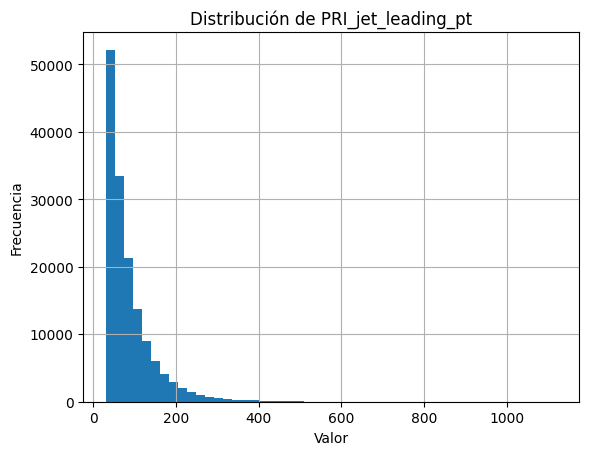

In [80]:
X['PRI_jet_leading_pt'].hist(bins=50)
plt.title('Distribución de PRI_jet_leading_pt')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

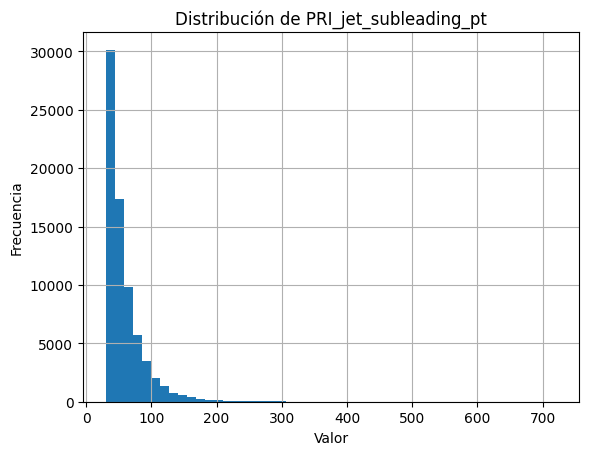

In [75]:
X['PRI_jet_subleading_pt'].hist(bins=50)
plt.title('Distribución de PRI_jet_subleading_pt')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

DISTRIBUCIÓN NORMAL

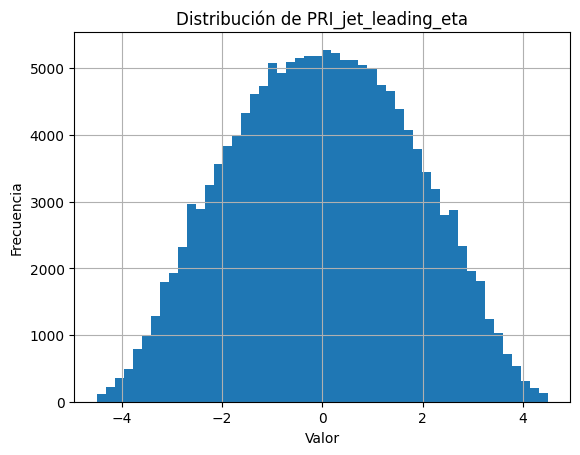

In [ ]:
X['PRI_jet_leading_eta'].hist(bins=50)
plt.title('Distribución de PRI_jet_leading_eta')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

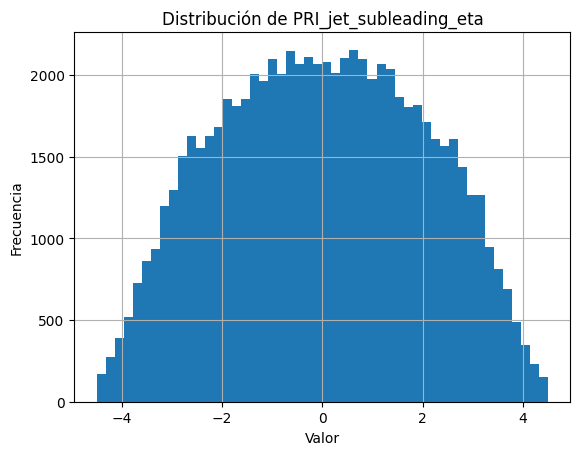

In [ ]:
X['PRI_jet_subleading_eta'].hist(bins=50)
plt.title('Distribución de PRI_jet_subleading_eta')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
print(X.isnull().sum())

EventId                             0
DER_mass_MMC                    38114
DER_mass_transverse_met_lep         0
DER_mass_vis                        0
DER_pt_h                            0
DER_deltaeta_jet_jet           177457
DER_mass_jet_jet               177457
DER_prodeta_jet_jet            177457
DER_deltar_tau_lep                  0
DER_pt_tot                          0
DER_sum_pt                          0
DER_pt_ratio_lep_tau                0
DER_met_phi_centrality              0
DER_lep_eta_centrality         177457
PRI_tau_pt                          0
PRI_tau_eta                         0
PRI_tau_phi                         0
PRI_lep_pt                          0
PRI_lep_eta                         0
PRI_lep_phi                         0
PRI_met                             0
PRI_met_phi                         0
PRI_met_sumet                       0
PRI_jet_num                         0
PRI_jet_leading_pt              99913
PRI_jet_leading_eta             99913
PRI_jet_lead

DISTRIBUCIÓN UNIFORME

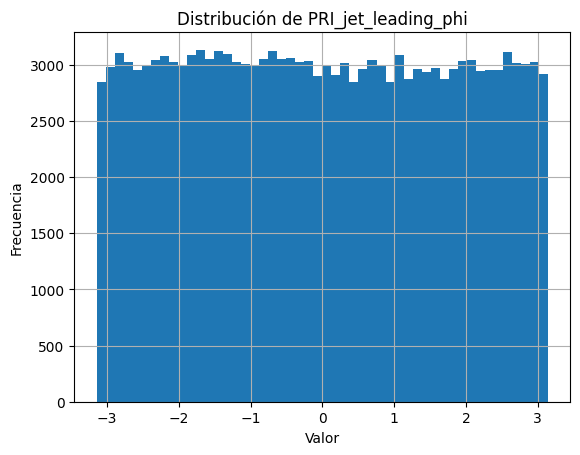

In [ ]:
X['PRI_jet_leading_phi'].hist(bins=50)
plt.title('Distribución de PRI_jet_leading_phi')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

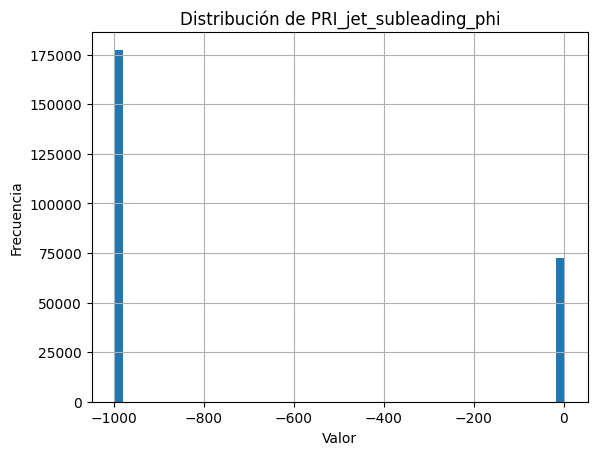

In [34]:


X['PRI_jet_subleading_phi'].hist(bins=50)
plt.title('Distribución de PRI_jet_subleading_phi')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

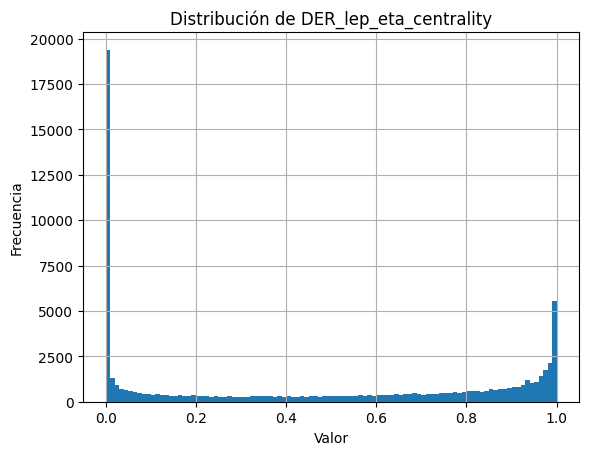

In [ ]:
attr = X['DER_lep_eta_centrality']
attr.hist(bins=100)
plt.title('Distribución de DER_lep_eta_centrality')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
print(min(X['DER_lep_eta_centrality']))

0.0


DER_mass_MMC                    38114
DER_mass_transverse_met_lep         0
DER_mass_vis                        0
DER_pt_h                            0
DER_deltaeta_jet_jet           177457
DER_mass_jet_jet               177457
DER_prodeta_jet_jet

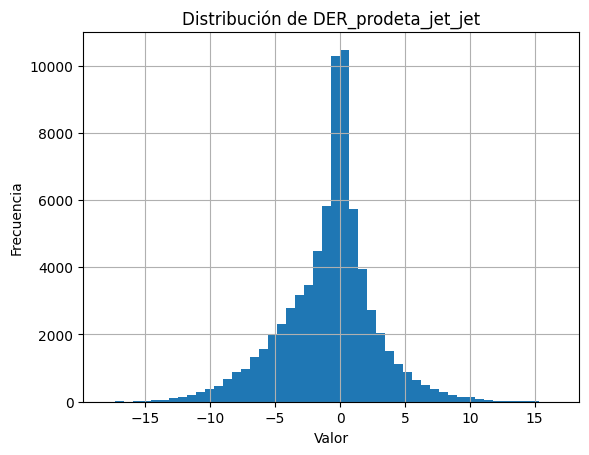

In [ ]:
X['DER_prodeta_jet_jet'].hist(bins=50)
plt.title('Distribución de DER_prodeta_jet_jet')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

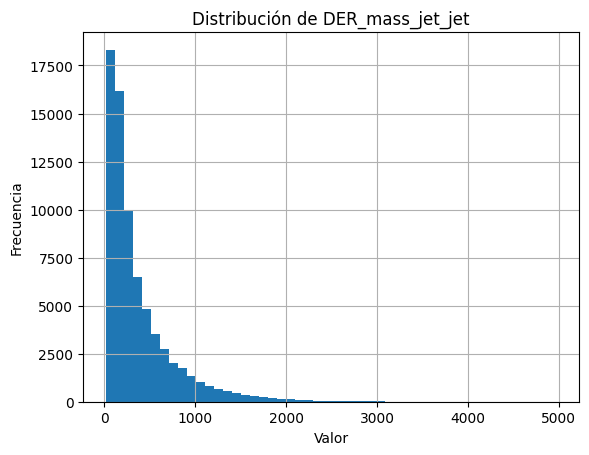

In [ ]:
X['DER_mass_jet_jet'].hist(bins=50)
plt.title('Distribución de DER_mass_jet_jet')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

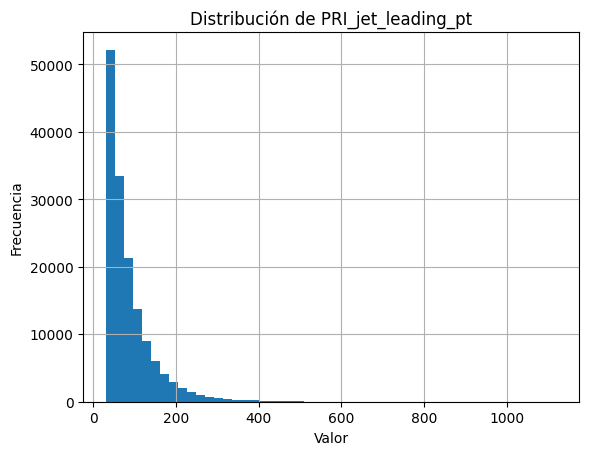

In [ ]:
X['PRI_jet_leading_pt'].hist(bins=50)
plt.title('Distribución de PRI_jet_leading_pt')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show() 

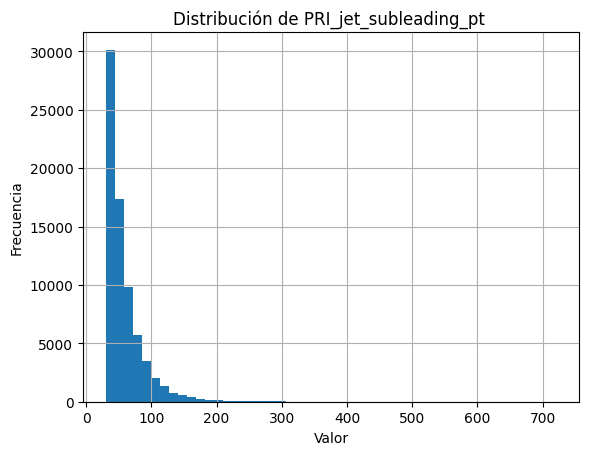

In [ ]:
X['PRI_jet_subleading_pt'].hist(bins=50)
plt.title('Distribución de PRI_jet_subleading_pt ')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()


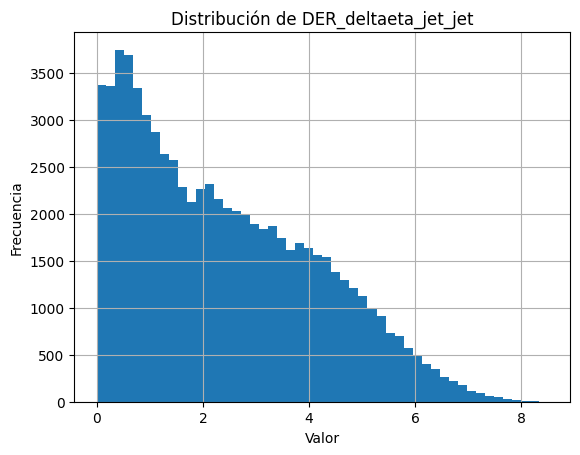

In [ ]:
X['DER_deltaeta_jet_jet'].hist(bins=50)
plt.title('Distribución de DER_deltaeta_jet_jet')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

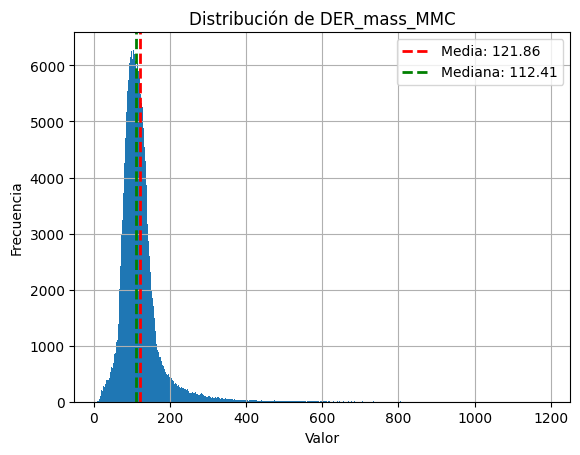

In [ ]:
X['DER_mass_MMC'].hist(bins=500)
plt.title('Distribución de DER_mass_MMC')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')

media = X['DER_mass_MMC'].mean()
mediana = X['DER_mass_MMC'].median()

plt.axvline(media, color='r', linestyle='dashed', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='g', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana:.2f}')

plt.legend()
plt.show()

In [ ]:
media = X['DER_mass_MMC'].mean()
mediana = X['DER_mass_MMC'].median()

fig = go.Figure()

fig.add_trace(go.Histogram(x=X['DER_mass_MMC'], nbinsx=500, name='DER_mass_MMC'))

fig.add_trace(go.Scatter(x=[media, media], y=[0, X['DER_mass_MMC'].count()], mode='lines', name=f'Media: {media:.2f}',
                         line=dict(color='red', dash='dash')))
fig.add_trace(go.Scatter(x=[mediana, mediana], y=[0, X['DER_mass_MMC'].count()], mode='lines', name=f'Mediana: {mediana:.2f}',
                         line=dict(color='green', dash='dash')))

fig.update_layout(title='Distribución de DER_mass_MMC',
                  xaxis_title='Valor',
                  yaxis_title='Frecuencia',
                  bargap=0.05)

fig.show()

# Pipeline

In [ ]:
X.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,-0.277,258.733,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497
1,100001,160.937,68.768,103.235,48.146,NaN,NaN,NaN,3.473,2.078,...,-1.916,164.546,1,46.226,0.725,1.158,NaN,NaN,NaN,46.226
2,100002,NaN,162.172,125.953,35.635,NaN,NaN,NaN,3.148,9.336,...,-2.186,260.414,1,44.251,2.053,-2.028,NaN,NaN,NaN,44.251
3,100003,143.905,81.417,80.943,0.414,NaN,NaN,NaN,3.310,0.414,...,0.060,86.062,0,NaN,NaN,NaN,NaN,NaN,NaN,-0.000
4,100004,175.864,16.915,134.805,16.405,NaN,NaN,NaN,3.891,16.405,...,-0.871,53.131,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000


In [65]:
import preprocess
import importlib
import sys
#sys.path.append('/utils/preprocess')
#importlib.reload(create_fullpipeline)

full_pipeline = preprocess.create_fullpipeline()
X_prepared = full_pipeline.fit_transform(X)

c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


In [ ]:
columns_transformed = [f'feature_{i}' for i in range(X_prepared.shape[1])]
X_prepared_df = pd.DataFrame(X_prepared, columns=columns_transformed, index=X.index)

print(X_prepared_df.isnull().sum())


feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
feature_20    0
feature_21    0
feature_22    0
feature_23    0
feature_24    0
feature_25    0
feature_26    0
feature_27    0
feature_28    0
feature_29    0
feature_30    0
feature_31    0
feature_32    0
feature_33    0
feature_34    0
feature_35    0
dtype: int64


In [ ]:
print(X.isnull().sum())

EventId                             0
DER_mass_MMC                    38114
DER_mass_transverse_met_lep         0
DER_mass_vis                        0
DER_pt_h                            0
DER_deltaeta_jet_jet           177457
DER_mass_jet_jet               177457
DER_prodeta_jet_jet            177457
DER_deltar_tau_lep                  0
DER_pt_tot                          0
DER_sum_pt                          0
DER_pt_ratio_lep_tau                0
DER_met_phi_centrality              0
DER_lep_eta_centrality         177457
PRI_tau_pt                          0
PRI_tau_eta                         0
PRI_tau_phi                         0
PRI_lep_pt                          0
PRI_lep_eta                         0
PRI_lep_phi                         0
PRI_met                             0
PRI_met_phi                         0
PRI_met_sumet                       0
PRI_jet_num                         0
PRI_jet_leading_pt              99913
PRI_jet_leading_eta             99913
PRI_jet_lead

In [21]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print(y_encoded[:10])

[1 0 0 0 0 0 1 1 0 1]


In [ ]:
print("Porcentaje de signals: ",sum(y_encoded)/len(y_encoded)*100)

Porcentaje de signals:  34.266799999999996


In [ ]:
X_prepared_df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35
0,1.556350,1.142622,0.341522,1.579473,0.0,0.0,1.0,0.0,0.444,-2.475,...,-0.270811,0.846712,0.214212,0.225054,1.812288,-1.352820,-0.756757,-0.147267,0.386847,0.412510
1,0.525758,0.000489,0.766558,0.086029,0.0,1.0,0.0,0.0,1.158,-2.475,...,0.147536,1.688504,-1.652849,-0.441526,0.411475,0.032730,0.090798,-1.051683,-0.357719,-0.273820
2,1.486197,0.000489,-0.151562,0.086029,0.0,1.0,0.0,0.0,-2.028,-2.475,...,-0.292406,-0.571650,-1.147554,3.387682,-0.737951,0.555132,0.382001,-1.200672,0.400135,-0.293970
3,0.001422,0.000489,0.444343,0.086029,1.0,0.0,0.0,0.0,-2.028,-2.475,...,-0.716598,-1.354138,0.010002,0.301873,-0.397234,-1.730447,-0.323312,0.038692,-0.978149,-0.745439
4,0.001422,0.000489,1.048950,0.086029,1.0,0.0,0.0,0.0,-2.028,-2.475,...,-0.468428,-1.800568,-1.223513,-0.765298,0.646261,0.839728,-1.185429,-0.475042,-1.238475,-0.745439


In [ ]:
X_prepared_df.corr()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35
feature_0,1.000000,-0.157570,0.001966,-0.002143,0.001160,0.000565,-0.000175,-0.002672,-0.004642,0.000956,...,0.000317,0.163124,0.001642,0.002827,1.777681e-01,0.003044,-0.001204,0.002005,-0.000638,-0.000580
feature_1,-0.157570,1.000000,0.002843,-0.002403,0.000399,0.000328,-0.001421,0.000783,0.001345,0.001825,...,-0.000648,0.080489,0.001248,0.000821,8.383508e-02,-0.003135,0.002428,-0.004349,-0.000510,-0.000997
feature_2,0.001966,0.002843,1.000000,0.006247,-0.029479,0.010292,0.015541,0.012119,0.002925,0.003121,...,0.255751,0.002514,-0.003215,0.321339,3.836594e-03,-0.002977,0.075356,0.000406,0.096363,0.022432
feature_3,-0.002143,-0.002403,0.006247,1.000000,0.070191,0.057687,-0.181462,0.041247,-0.001820,0.001303,...,-0.053910,0.001503,0.000325,0.004424,6.706010e-04,0.000116,-0.033926,0.000724,-0.055465,-0.085312
feature_4,0.001160,0.000399,-0.029479,0.070191,1.000000,-0.547110,-0.409884,-0.254479,-0.000976,0.002041,...,-0.170909,-0.009331,-0.003362,-0.158853,-2.115838e-02,-0.000535,-0.252512,-0.006449,-0.541379,-0.608208
feature_5,0.000565,0.000328,0.010292,0.057687,-0.547110,1.000000,-0.336866,-0.209145,-0.000449,-0.000974,...,-0.003532,0.005102,0.000317,0.003230,1.388471e-02,0.000499,-0.032491,0.001680,-0.034309,-0.055089
feature_6,-0.000175,-0.001421,0.015541,-0.181462,-0.409884,-0.336866,1.000000,-0.156688,0.000152,0.001188,...,0.133254,0.004219,0.004177,0.097531,6.370317e-03,0.000906,0.183877,0.003731,0.342382,0.395247
feature_7,-0.002672,0.000783,0.012119,0.041247,-0.254479,-0.209145,-0.156688,1.000000,0.002199,-0.003610,...,0.112216,0.001822,-0.000617,0.130848,4.876083e-03,-0.001169,0.228524,0.003115,0.505588,0.579962
feature_8,-0.004642,0.001345,0.002925,-0.001820,-0.000976,-0.000449,0.000152,0.002199,1.000000,-0.027466,...,0.003327,-0.001435,-0.112980,0.001251,-2.137146e-03,-0.171878,0.003296,-0.174516,0.005004,0.001961
feature_9,0.000956,0.001825,0.003121,0.001303,0.002041,-0.000974,0.001188,-0.003610,-0.027466,1.000000,...,-0.004612,0.001850,-0.030451,-0.001163,2.984303e-03,-0.041759,-0.002498,-0.037651,-0.004076,-0.005391


In [ ]:
weights = weights / weights.max()
print(weights)

0         0.000339
1         0.285532
2         0.300080
3         0.696241
4         0.798376
            ...   
249995    0.575910
249996    0.319239
249997    0.002382
249998    0.214970
249999    0.240008
Name: Weight, Length: 250000, dtype: float64


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
     X, y_encoded, weights, test_size=0.20, random_state=4546546)

X_val, X_test, y_val, y_test, weights_val, weights_test  = train_test_split(X_test, y_test, weights_test,  test_size=0.25, random_state=4546546)

## Regresion logistica

In [ ]:
from comet_ml import Experiment
from comet_ml.integration.pytorch import log_model

experiment = Experiment(
  api_key="tZzHrgZeB2lMeZSSnDvSFUAIV",
  project_name="proyecto-1-taa",
  workspace="xqft"
)

experiment.set_name('Regresion logistica')

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.com/xqft/proyecto-1-taa/7bf8fd5f14904abca52e1462f757e389
COMET INFO:   Others:
COMET INFO:     Name : Regresion logistica
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     filename            : 1
COMET INFO:     installed packages  : 1
COMET INFO:     notebook            : 1
COMET INFO:     os packages         : 1
COMET INFO:     source_code         : 1
COMET INFO: 
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn.
COMET WARNING: As you are 

In [23]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression

from utils.preprocess import DataPreprocessor
preprocess = DataPreprocessor()

classifier = Pipeline([
    ('preprocess', preprocess),
    ('logistic', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
classifier.fit(X_train, pd.Series(y_train), logistic__sample_weight=weights_train)

Pipeline(steps=[('preprocess', DataPreprocessor()),
                ('logistic',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [24]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

y_pred = classifier.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred, sample_weight=weights_test)

precision = precision_score(y_test, y_pred, average='binary', sample_weight=weights_test)
recall = recall_score(y_test, y_pred, average='binary', sample_weight=weights_test)
f1 = f1_score(y_test, y_pred, average='binary', sample_weight=weights_test)
accuracy = accuracy_score(y_test, y_pred, sample_weight=weights_test)

print("Matriz de confusión:\n", conf_matrix)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy Score:", accuracy)

Matriz de confusión:
 [[2.02676909e+04 1.37959907e-01]
 [3.41714523e+01 2.31442312e-02]]
Precision: 0.14366006616147653
Recall: 0.0006768388437820641
F1 Score: 0.0013473298887051247
Accuracy Score: 0.9983100496248406


In [ ]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

classifier_1 = make_pipeline(full_pipeline, LogisticRegression(max_iter=1000))

param_grid = {
    'logisticregression__class_weight': [None, 'balanced'],
    'logisticregression__C': [0.01, 0.1, 1, 10, 100]
}

scorers = {
    'precision_score': make_scorer(precision_score),
    'recall_score': make_scorer(recall_score),
    'f1_score': make_scorer(f1_score)
}

grid_search = GridSearchCV(classifier_1, param_grid, scoring=scorers, refit='f1_score', cv=5, verbose=3)

grid_search.fit(X_train, y_train)

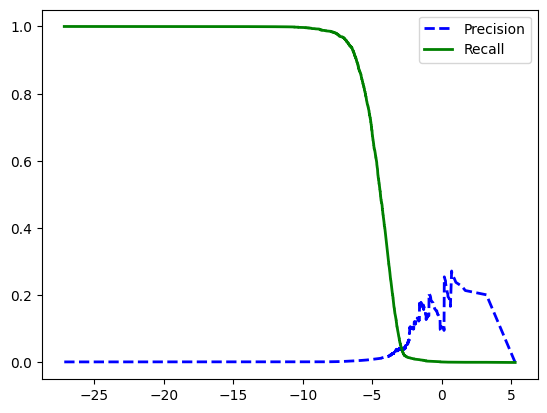

In [ ]:
y_test_scores = classifier.decision_function(X_test)

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_scores, sample_weight=weights_test)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
#plt.vlines(thresholds, 0, 1.0, "k", "dotted", label="threshold")
plt.legend()
plt.show()


In [ ]:
experiment.log_metrics({
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
})

experiment.log_curve("threshold-recall", thresholds, precisions[:-1])
experiment.log_curve("threshold-precision", thresholds, recalls[:-1])


NameError: name 'experiment' is not defined

In [ ]:
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.com/xqft/proyecto-1-taa/9151827848f34adaa06fa27caf12d409
COMET INFO:   Metrics:
COMET INFO:     Accuracy  : 0.8333182761986695
COMET INFO:     F1 Score  : 0.013831355680318541
COMET INFO:     Precision : 0.006985286874841229
COMET INFO:     Recall    : 0.6939902825576061
COMET INFO:   Others:
COMET INFO:     Name : Regresion logistica
COMET INFO:   Uploads:
COMET INFO:     curve               : 2
COMET INFO:     environment details : 1
COMET INFO:     filename            : 1
COMET INFO:     installed packages  : 1
COMET INFO:     notebook            : 1
COMET INFO:     os packages         : 1
COMET INFO:     source_code         : 1


## Regresion lineal

In [ ]:
experiment = Experiment(
  api_key="tZzHrgZeB2lMeZSSnDvSFUAIV",
  project_name="proyecto-1-taa",
  workspace="xqft"
)

experiment.set_name('Regresion lineal')

In [25]:
from sklearn.linear_model import LinearRegression

from utils.preprocess import DataPreprocessor
preprocess = DataPreprocessor()

classifier_LR = make_pipeline(preprocess, LinearRegression(positive = True))
classifier_LR.fit(X_train, pd.Series(y_train),linearregression__sample_weight=weights_train)

Pipeline(steps=[('datapreprocessor', DataPreprocessor()),
                ('linearregression', LinearRegression(positive=True))])

In [27]:
from sklearn.metrics import mean_squared_error, r2_score

#se = mean_squared_error(y_test, y_pred_LR, sample_weight=weights_test)
#r2 = r2_score(y_test, y_pred_LR, sample_weight=weights_test)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

threshold = 0.5
y_pred_class = np.where(y_pred_LR > threshold, 1, 0)

conf_matrix = confusion_matrix(y_test, y_pred_class, sample_weight=weights_test)

conf_matrix

NameError: name 'mse' is not defined

In [40]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

y_pred_LR = classifier_LR.predict(X_test) < 0.5

conf_matrix = confusion_matrix(y_test, y_pred_LR, sample_weight=weights_test)

precision = precision_score(y_test, y_pred_LR, average='binary', sample_weight=weights_test)
recall = recall_score(y_test, y_pred_LR, average='binary', sample_weight=weights_test)
f1 = f1_score(y_test, y_pred_LR, average='binary', sample_weight=weights_test)
accuracy = accuracy_score(y_test, y_pred_LR, sample_weight=weights_test)

print("Matriz de confusión:\n", conf_matrix)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy Score:", accuracy)

Matriz de confusión:
 [[    0.         20267.82887689]
 [    0.            34.19459651]]
Precision: 0.001684294994250959
Recall: 1.0
F1 Score: 0.003362925829361487
Accuracy Score: 0.0016842949942508822


In [ ]:
y_test_scores = classifier_LR.decision_function(X_test)

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_scores, sample_weight=weights_test)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
#plt.vlines(thresholds, 0, 1.0, "k", "dotted", label="threshold")
plt.legend()
plt.show()

In [ ]:
experiment.log_metrics({
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
})

experiment.log_curve("threshold-recall", thresholds, precisions[:-1])
experiment.log_curve("threshold-precision", thresholds, recalls[:-1])
experiment.end()

## Support Vector Machine

In [ ]:
experiment = Experiment(
  api_key="tZzHrgZeB2lMeZSSnDvSFUAIV",
  project_name="proyecto-1-taa",
  workspace="xqft"
)

experiment.set_name('Support Vector Machine Lineal')

In [43]:
from sklearn import svm
classifier_svm = make_pipeline(preprocess, svm.SVC(kernel='rbf'))
classifier_svm.fit(X_train, pd.Series(y_train),svc__sample_weight=weights_train)

Pipeline(steps=[('datapreprocessor', DataPreprocessor()), ('svc', SVC())])

In [44]:
y_pred_SVM = classifier_svm.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred_SVM, sample_weight=weights_test)

precision = precision_score(y_test, y_pred_SVM, average='binary', sample_weight=weights_test)
recall = recall_score(y_test, y_pred_SVM, average='binary', sample_weight=weights_test)
f1 = f1_score(y_test, y_pred_SVM, average='binary', sample_weight=weights_test)
accuracy = accuracy_score(y_test, y_pred_SVM, sample_weight=weights_test)

print("Matriz de confusión:\n", conf_matrix)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy Score:", accuracy)

Matriz de confusión:
 [[20267.82887689     0.        ]
 [   34.19459651     0.        ]]
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Accuracy Score: 0.9983157050057491


/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


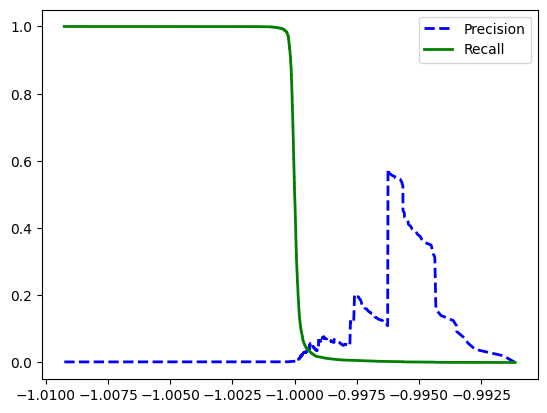

In [45]:
y_test_scores = classifier_svm.decision_function(X_test)

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_scores, sample_weight=weights_test)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
#plt.vlines(thresholds, 0, 1.0, "k", "dotted", label="threshold")
plt.legend()
plt.show()

In [ ]:
experiment.log_metrics({
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
})

experiment.log_curve("threshold-recall", thresholds, precisions[:-1])
experiment.log_curve("threshold-precision", thresholds, recalls[:-1])
experiment.end()

## 

In [ ]:
def find_best_logistic_regression_model(y, tx, jet_string, max_iter=100, gamma=0.05, k_fold=3) :
    """Computes the best logistic regression model for the given `y` and `tx`"""

    lambdas = np.logspace(-24, 3, 13)
    degrees = np.arange(1, 8)

    results = np.zeros((len(degrees), len(lambdas)))

    for i_degree, degree in enumerate(degrees) : 
        expanded_tx = polynomial_expansion(tx, degree)
        for i_lambda, lambda_  in enumerate(lambdas) : 
            results[i_degree, i_lambda] = cross_validate_logistic_regression(y, expanded_tx, max_iter, gamma, lambda_, k_fold)
            print("degree={d},\t lambda={l:e},\taccuracy={a}".format(d=degree, l=lambda_, a=results[i_degree, i_lambda]))

    disk_helpers.save_data('logistic-regression', jet_string, degrees, lambdas, results)
    i,j = np.unravel_index(np.argmax(results, axis=None), results.shape)

    return degrees[i], lambdas[j], results[i, j]

In [ ]:
def polynomial_expansion(x, degree, mixed_columns=False):
    """
    Expand the given vector to a polynomial of degree-th degree
    :param x: vector that will get expanded
    :param degree: number of newly added polynomial degrees
    :param mixed_columns: products among all columns
    :return: result of the expansion
    """
    x_expanded = np.ones((len(x), 1))
    for d in range(1, degree + 1):
        x_expanded = np.c_[x_expanded, np.power(x, d)]

    # products between all columns of degree 1 
    if mixed_columns : 
        n = x.shape[1]
        r,c = np.triu_indices(n,1)
        out0 = x[:,r] * x[:,c]
        out = np.concatenate(( x, out0), axis=1)
        x_expanded = np.c_[x_expanded, out]

    return x_expanded

In [ ]:
def find_best_logistic_regression_model(y, tx, jet_string, max_iter=100, gamma=0.05, k_fold=3) :
    """Computes the best logistic regression model for the given `y` and `tx`"""

    lambdas = np.logspace(-24, 3, 13)
    degrees = np.arange(1, 8)

    results = np.zeros((len(degrees), len(lambdas)))

    for i_degree, degree in enumerate(degrees) : 
        expanded_tx = polynomial_expansion(tx, degree)
        for i_lambda, lambda_  in enumerate(lambdas) : 
            results[i_degree, i_lambda] = cross_validate_logistic_regression(y, expanded_tx, max_iter, gamma, lambda_, k_fold)
            print("degree={d},\t lambda={l:e},\taccuracy={a}".format(d=degree, l=lambda_, a=results[i_degree, i_lambda]))

    disk_helpers.save_data('logistic-regression', jet_string, degrees, lambdas, results)
    i,j = np.unravel_index(np.argmax(results, axis=None), results.shape)

    return degrees[i], lambdas[j], results[i, j]

In [ ]:
# -*- coding: utf-8 -*-
"""Logistic regression functions"""

import math
import numpy as np


def build_k_indices(y, k_fold, seed):
    """build k indices for k-fold."""
    num_row = y.shape[0]
    interval = int(num_row / k_fold)
    np.random.seed(seed)
    indices = np.random.permutation(num_row)
    k_indices = [indices[k * interval: (k + 1) * interval]
                 for k in range(k_fold)]
    return np.array(k_indices)

def sigmoid(t):
    """apply the sigmoid function on t."""
    out = np.ones((len(t), 1))
    to_be_computed = np.logical_and(t < 30, t > -30)
    out[to_be_computed] = 1 / (1 + np.exp(-t[to_be_computed]))
    out[t > -30] = 0
    return out


def calculate_loss(y, tx, w):
    """compute the loss: negative log likelihood."""
    prod = tx @ w
    a = prod
    a[prod < (-10)] = 0
    a[prod > 10] = prod[prod > 10]
    incl = np.logical_and(prod <= -10, prod <= 10)
    a[incl] = np.log(1 + np.exp(prod[incl]))
    b = y * prod
    return sum(a - b)


def calculate_gradient(y, tx, w):
    """compute the gradient of loss."""
    return tx.T @ (sigmoid(tx @ w) - y)


def learning_by_gradient_descent(y, tx, w, gamma):
    """
    Do one step of gradient descent using logistic regression.
    Return the loss and the updated w.
    """
    loss = calculate_loss(y, tx, w)
    gradient = calculate_gradient(y, tx, w)
    w = w - gamma * gradient
    return loss, w


def penalized_logistic_regression(y, tx, w, lambda_):
    """return the loss, gradient"""
    loss = calculate_loss(y, tx, w) + lambda_ * math.pow(np.linalg.norm(w), 2)
    gradient = calculate_gradient(y, tx, w) + 2 * lambda_ * w
    return loss, gradient


def learning_by_penalized_gradient(y, tx, w, gamma, lambda_):
    """
    Do one step of gradient descent, using the penalized logistic regression.
    Return the loss and updated w.
    """
    loss, grad = penalized_logistic_regression(y, tx, w, lambda_)
    updated_w = w - gamma * grad
    return loss, updated_w


def logistic_regression_penalized_gradient_descent(y, tx, gamma, lambda_, max_iter):
    threshold = 1e+0
    losses = []
    w = np.zeros((tx.shape[1], 1))

    for i in range(max_iter):
        loss, w = learning_by_penalized_gradient(y, tx, w, gamma, lambda_)
        losses.append(loss)
        if len(losses) > 1 and np.abs(losses[-1] - losses[-2]) < threshold:
            break

    return w


def cross_validate_logistic_regression(y, tx, max_iter, gamma, lambda_, k_fold):
    seed = 1
    k_indices = build_k_indices(y, k_fold, seed)
    classifications = []

    for k in range(k_fold):
        test_indices = np.zeros(len(y)).astype(bool)
        test_indices[k_indices[k]] = True
        train_indices = (~test_indices).tolist()
        test_indices = test_indices.tolist()

        tx_train = tx[train_indices, :]
        y_train = y[train_indices]

        tx_test = tx[test_indices, :]
        y_test = y[test_indices]

        w = logistic_regression_penalized_gradient_descent(y_train, tx_train, gamma, lambda_, max_iter)
        classified = sum(predict_labels(w, tx_test) == y_test) / len(y_test)
        classifications.append(classified)

    return np.mean(classifications)

In [ ]:
find_best_logistic_regression_model(y_train, X_train, 'jet2')


NameError: name 'find_best_logistic_regression_model' is not defined

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

max_iter = 1000
gamma = 0.1  
lambda_ = 1  
k_fold = 5
C = 1 / lambda_

log_reg = LogisticRegression(C=C, penalty='l2', max_iter=max_iter, solver='lbfgs')

scores = cross_val_score(log_reg, X_prepared_df, y, cv=k_fold, scoring='accuracy')

mean_accuracy = scores.mean()
print(f'La precisión promedio de la validación cruzada es: {mean_accuracy}')

La precisión promedio de la validación cruzada es: 0.753768


In [ ]:
X_train = std_pipeline.fit_transform(X_train)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
X_test = std_pipeline.fit_transform(X_test)
y_pred = log_reg.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred, sample_weight=weights_test)

precision = precision_score(y_test, y_pred, average='binary', sample_weight=weights_test)
recall = recall_score(y_test, y_pred, average='binary', sample_weight=weights_test)
f1 = f1_score(y_test, y_pred, average='binary', sample_weight=weights_test)
accuracy = accuracy_score(y_test, y_pred, sample_weight=weights_test)

print("Matriz de confusión:\n", conf_matrix)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy Score:", accuracy)

Matriz de confusión:
 [[2.40448557e+03 1.86466003e+02]
 [2.17200422e+00 2.19928507e+00]]
Precision: 0.01165707323506491
Recall: 0.5031204583160885
F1 Score: 0.02278620052035923
Accuracy Score: 0.9273161694607367


In [ ]:
print(len(y_pred))
print(sum(y_pred))

12500
3442


In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

clf = RandomForestClassifier(n_estimators=100,
                             random_state=454642) 

clf.fit(X_train, y_train, sample_weight=weights_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'La precisión del modelo de Random Forest es: {accuracy}')
print(clf.feature_importances_)

NameError: name 'X_train' is not defined

In [ ]:
X = std_pipeline.fit_transform(X)

clf = RandomForestClassifier(n_estimators=100,
                             random_state=454642) 

clf.fit(X, y, sample_weight=weights)

# y_pred = clf.predict(X_test)

RandomForestClassifier(random_state=454642)

In [ ]:
test = pd.read_csv('test.csv')

print_()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
0,350000,-999.000,79.589,23.916,3.036,-999.000,-999.000,-999.000,0.903,3.036,...,2.022,98.556,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-0.000
1,350001,106.398,67.490,87.949,49.994,-999.000,-999.000,-999.000,2.048,2.679,...,-1.138,176.251,1,47.575,-0.553,-0.849,-999.000,-999.000,-999.000,47.575
2,350002,117.794,56.226,96.358,4.137,-999.000,-999.000,-999.000,2.755,4.137,...,-1.868,111.505,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,0.000
3,350003,135.861,30.604,97.288,9.104,-999.000,-999.000,-999.000,2.811,9.104,...,1.172,164.707,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,0.000
4,350004,74.159,82.772,58.731,89.646,1.347,536.663,-0.339,1.028,77.213,...,-0.231,869.614,3,254.085,-1.013,-0.334,185.857,0.335,2.587,599.213


In [ ]:
y_pred = clf.predict(test)
y_proba = clf.predict_proba(test)

/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/base.py:443: UserWarning:

X has feature names, but RandomForestClassifier was fitted without feature names

/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/base.py:443: UserWarning:

X has feature names, but RandomForestClassifier was fitted without feature names



In [ ]:
probabilidades_clase_positiva = y_proba[:, 0]
event_id =[ i-349999 for i in test["EventId"]]

indices_ordenados = np.argsort(probabilidades_clase_positiva)

event_id_ordenados = [event_id[i] for i in indices_ordenados]


In [ ]:
print(max(event_id))

550000


In [ ]:
event_id_ordenados = [i+1 for i in range(len(test))]

In [ ]:
import pandas as pd

submission_df = pd.DataFrame({
    "EventId": test["EventId"],
    "Class": y_pred ,
    "RankOrder": event_id_ordenados
})

# Guardar el DataFrame como un archivo CSV
submission_df.to_csv("submission.csv", index=False)


In [ ]:
!kaggle competitions submit -c higgs-boson -f submission.csv -m "First submissions"

100%|██████████████████████████████████████| 8.29M/8.29M [00:03<00:00, 2.83MB/s]
Successfully submitted to Higgs Boson Machine Learning Challenge

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

y_pred = clf.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred, sample_weight=weights_test)

precision = precision_score(y_test, y_pred, average='binary', sample_weight=weights_test)
recall = recall_score(y_test, y_pred, average='binary', sample_weight=weights_test)
f1 = f1_score(y_test, y_pred, average='binary', sample_weight=weights_test)
accuracy = accuracy_score(y_test, y_pred, sample_weight=weights_test)

print("Matriz de confusión:\n", conf_matrix)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy Score:", accuracy)

Matriz de confusión:
 [[2.30125223e+03 2.89699340e+02]
 [1.10640280e+00 3.26488650e+00]]
Precision: 0.01114431798882781
Recall: 0.7468932564100207
F1 Score: 0.021960958755231384
Accuracy Score: 0.8879500707088613


In [ ]:
from HiggsBosonCompetition_AMSMetric_rev1 import AMS

y_pred_decoded = encoder.inverse_transform(y_pred)
ams = AMS((y_pred_decoded == 's').sum(), (y_pred_decoded == 'b').sum())
ams

48.21089077133308

In [ ]:
encoder

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import validation_curve
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)

param_range = np.arange(1, 250, 25)

train_scores, test_scores = validation_curve(
    RandomForestClassifier(),
    X, y, 
    param_name="n_estimators", 
    param_range=param_range,
    scoring="accuracy", 
    n_jobs=-1, 
    cv=5)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, color="blue", marker="o", markersize=5, label="Entrenamiento")
plt.fill_between(param_range, train_mean + train_std, train_mean - train_std, alpha=0.15, color="blue")
plt.plot(param_range, test_mean, color="green", linestyle="--", marker="s", markersize=5, label="Validación")
plt.fill_between(param_range, test_mean + test_std, test_mean - test_std, alpha=0.15, color="green")

plt.title("Curva de Validación para Random Forest")
plt.xlabel("Número de Árboles")
plt.ylabel("Precisión")
plt.legend(loc="lower right")
plt.grid()
plt.xscale("linear")  # O 'log' si prefieres una escala logarítmica
plt.show()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=eef18a2a-bd90-4787-a663-6232ae27b564' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>